In [1]:
from football_dataset_xDiyo import *
from utils_xDiyo import *
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import precision_score, recall_score, mean_squared_error, mean_absolute_error,accuracy_score, f1_score
import matplotlib.pyplot as plt
import random
from torch.profiler import profile, ProfilerActivity
import math
from sklearn.manifold import TSNE

In [2]:
random.seed(69)
np.random.seed(69)
torch.manual_seed(69)
if torch.cuda.is_available():
    torch.cuda.manual_seed(69)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [17]:
test_names = ['Premier_League_20_21','Premier_League_21_22','Premier_League_22_23','Premier_League_23_24','Premier_League_24_25',
            'La_Liga_20_21','La_Liga_21_22','La_Liga_22_23','La_Liga_23_24','La_Liga_24_25',
            'Serie_A_20_21','Serie_A_21_22','Serie_A_22_23', 'Serie_A_23_24', 'Serie_A_24_25',
            'Bundesliga_20_21','Bundesliga_21_22','Bundesliga_22_23', 'Bundesliga_23_24', 'Bundesliga_24_25']
train_df,val_df,test_df = split_and_merge_leagues(test_names, 0.80, 0.15, 0.05)
atk_headers,def_headers = divide_stats(stat_type='older_stats')
atk_avgs = calculate_mean_std(train_df, atk_headers)
def_avgs = calculate_mean_std(train_df, def_headers)
mu_atk,sigma_atk = extract_averages(atk_avgs, atk_headers)
mu_def,sigma_def = extract_averages(def_avgs, def_headers)
team_names = ['<PAD>']+sorted(train_df['home_team'].unique())
team2id = {name: idx for idx, name in enumerate(team_names)}
test_df['home_formation']=test_df['home_formation'].apply(fix_formation)
test_df['away_formation']=test_df['away_formation'].apply(fix_formation)

In [18]:
history_len = 8
raw_train = FootballDataset(train_df, history_len, team2id, stat_type='older_stats')
raw_val = FootballDataset(val_df, history_len, team2id, stat_type='older_stats')
raw_test = FootballDataset(test_df, history_len, team2id, stat_type='older_stats')

In [ ]:
precompute_data(raw_train, f'data/{history_len}/train', start_idx=0)
precompute_data(raw_val, f'data/{history_len}/val', start_idx=0)
precompute_data(raw_test, f'data/{history_len}/test', start_idx=0)

In [20]:
# Directories for precomputed data
precomputed_dir = f'data/{history_len}'

# Build datasets from precomputed files
train_dataset = build_datasets_from_files(f'{precomputed_dir}/train')
val_dataset = build_datasets_from_files(f'{precomputed_dir}/val')
test_dataset = build_datasets_from_files(f'{precomputed_dir}/test')

# Build dataloaders
batch_size = 1024
train_loader = build_train_loader(train_dataset, batch_size=batch_size)
val_loader = build_val_loader(val_dataset, batch_size=batch_size)
test_loader = build_test_loader(test_dataset, batch_size=batch_size)

In [21]:
data_iter = iter(test_loader)
batch_data = next(data_iter)

In [22]:
class CreateEmbMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=None, num_layers=1, dropout=0.0, bias=None):
        super().__init__()
        self.num_layers = num_layers
        if num_layers == 1:
            final_layer = nn.Linear(input_dim, output_dim)
            if bias is not None:
                # Expecting bias to be a tensor of shape (output_dim,)
                if bias.shape != final_layer.bias.shape:
                    raise ValueError(f"Bias tensor shape mismatch. Expected {final_layer.bias.shape}, got {bias.shape}")
                final_layer.bias.data.copy_(bias)
            self.layers = final_layer
        else:
            hidden_dim = hidden_dim if hidden_dim is not None else input_dim
            net = []
            # First layer
            net.append(nn.Linear(input_dim, hidden_dim))
            net.append(nn.Tanh())
            if dropout > 0:
                net.append(nn.Dropout(dropout))
            # Hidden layers
            for _ in range(num_layers - 2):
                net.append(nn.Linear(hidden_dim, hidden_dim))
                net.append(nn.Tanh())
                if dropout > 0:
                    net.append(nn.Dropout(dropout))
            # Final output layer
            final_layer = nn.Linear(hidden_dim, output_dim)
            if bias is not None:
                if bias.shape != final_layer.bias.shape:
                    raise ValueError(f"Bias tensor shape mismatch. Expected {final_layer.bias.shape}, got {bias.shape}")
                final_layer.bias.data.copy_(bias)
            net.append(final_layer)
            self.layers = nn.Sequential(*net)

    def forward(self, x):
        return self.layers(x)
    
class TeamDense(nn.Module):
    def __init__(self, num_teams, embed_dim, pad_idx=0):
        """
        num_teams: Number of distinct teams (including <PAD>).
        embed_dim: Embedding dimensionality.
        pad_idx:   Index representing <PAD>.
        """
        super().__init__()
        self.embedding = nn.Embedding(num_teams, embed_dim, padding_idx=pad_idx)
        #self.fc = nn.Sequential(
        #    nn.Linear(embed_dim , embed_dim),
        #    nn.Tanh()
        #)

    def forward(self, team_ids):
        """
        team_ids: LongTensor of shape (batch_size, max_seq_length)
                containing the integer IDs of teams (including <PAD> for padding).

        Returns: A FloatTensor of shape (batch_size, max_seq_length, embed_dim).
                Padded positions will automatically have embedding vectors of zeros
                because we specified padding_idx in nn.Embedding.
        """
        # The embedding layer looks up embeddings for all valid indices
        # and returns them in the same shape as `team_ids`, but with an extra embed_dim dimension.
        embedded = self.embedding(team_ids)  # (batch_size, max_seq_length, embed_dim)
        #embedded = self.fc(embedded)
        return embedded


class TeamEmbedding(nn.Module):
    def __init__(self, embed_dim, num_teams, mu_sigma, pad_idx=0, stats_hidden_dim=None, 
                coupled = False, device = 'cuda'):
        super(TeamEmbedding, self).__init__()
        
        self.device = device
        
        self.mu_atk, self.sigma_atk, self.mu_def, self.sigma_def = mu_sigma
        
        
        self.mu_atk = self.mu_atk.to(self.device)
        self.sigma_atk = self.sigma_atk.to(self.device)
        self.mu_def = self.mu_def.to(self.device)
        self.sigma_def = self.sigma_def.to(self.device)
        self.stats_dim = len(self.mu_atk)+len(self.mu_def)
        
        self.coupled = coupled
        
        
        # Embedding layer
        self.embedding_layer = TeamDense(num_teams, embed_dim, pad_idx)
        
        if self.coupled:
            self.prediction = CreateEmbMLP((embed_dim + 2)*2, 2*self.stats_dim, hidden_dim = stats_hidden_dim, num_layers = 5,
                                        dropout=0.0)
        else:
            self.prediction = CreateEmbMLP(embed_dim + 2, self.stats_dim, hidden_dim = stats_hidden_dim, num_layers = 3,
                                        dropout=0.0)
        
        

    def forward(self, batch):

        batch = standardize_stats(batch, self.mu_atk, self.sigma_atk, self.mu_def, self.sigma_def)
        
        batch_size = batch['home_team_atk'].shape[0]
        #consecutive = 1
        
        # Obtain masks and lengths for both teams
        valid_home_mask = batch['home_team_valid_mask']
        valid_away_mask = batch['away_team_valid_mask']
        home_scores_lengths = batch['home_team_scores_lengths'].to('cpu')
        away_scores_lengths = batch['away_team_scores_lengths'].to('cpu')
        
        # Split recent data

        home_team_atk = batch['home_team_atk'][:,-1:,:]
        home_team_def = batch['home_team_def'][:,-1:,:]
        away_team_atk = batch['away_team_atk'][:,-1:,:]
        away_team_def = batch['away_team_def'][:,-1:,:]
        
        home_team_is_home = batch['home_team_is_home'][:,-1:]
        home_team_standings = batch['home_team_standings'][:,-1:]
        # home_team_scores = batch['home_team_scores'][:,-1]
        away_team_is_home = batch['away_team_is_home'][:,-1:]
        away_team_standings = batch['away_team_standings'][:,-1:]
        # away_team_scores = batch['away_team_scores'][:,-1]
        #home_team_formation = batch['home_team_formations'][:,-1:].squeeze(-1)
        #away_team_formation = batch['away_team_formations'][:,-1:].squeeze(-1)

        # Select and stack indexes and names
        home_team_indexes = batch['home_team_index'][:,-1:]
        away_team_indexes = batch['away_team_index'][:,-1:]
        home_team_names = [name for names in batch['home_team_names'] for name in names[-1:]]
        away_team_names = [name for names in batch['away_team_names'] for name in names[-1:]]
        all_indexes = torch.cat([home_team_indexes, away_team_indexes], dim=0)
        all_names = home_team_names + away_team_names

        # Compute and stack embeddings
        home_team_embed = self.embedding_layer(home_team_indexes)
        away_team_embed = self.embedding_layer(away_team_indexes)
        all_teams_embed = torch.cat([home_team_embed, away_team_embed], dim=0)
        
        # Combine attack, defense
        home_stats = torch.cat([home_team_atk, home_team_def], dim=-1)
        away_stats = torch.cat([away_team_atk, away_team_def], dim=-1)
        labels = torch.cat([home_stats, away_stats], dim=0).squeeze(1)
        

        # Predict stats from embeddings
        if self.coupled:
            home_away_input = torch.cat([home_team_embed,home_team_is_home,home_team_standings,
                                        away_team_embed, away_team_is_home, away_team_standings], dim=-1) 
            predicted_stats = self.prediction(home_away_input)
            # Splitting the predictions
            home_stats = predicted_stats[..., :self.stats_dim]
            away_stats = predicted_stats[..., self.stats_dim:]
            # Reshaping to the same shape of the labels
            home_away_stats = torch.cat([home_stats, away_stats], dim=0).squeeze(1)
        else:
            all_standings = torch.cat([home_team_standings, away_team_standings], dim=0)
            all_is_home = torch.cat([home_team_is_home, away_team_is_home], dim=0)
            home_away_input = torch.cat([all_teams_embed, all_is_home, all_standings], dim=-1)
            home_away_stats = self.prediction(home_away_input)
        

        
        return labels, home_away_stats, all_indexes, all_names, all_teams_embed
    
    def _embeds_only(self, indexes):
        return self.embedding_layer(indexes)
        
        


In [23]:
def train_autoencoder(model, train_loader, valid_loader, device, lr=1e-4, epochs=10):
    """
    Trains the model (autoencoder) using MSE loss.

    The model's forward should return a tuple:
        (labels, predicted_stats, all_indexes, all_names, all_teams_embed)
    where:
        - labels: Ground truth stats (Tensor)
        - predicted_stats: The reconstructed stats (Tensor)
    
    Args:
        model: Your autoencoder model (e.g., TeamEmbedding).
        train_loader: DataLoader for training samples.
        valid_loader: DataLoader for validation samples.
        device: The device to use ('cuda' or 'cpu').
        lr: Learning rate.
        epochs: Number of training epochs.

    Returns:
        (train_losses, valid_losses): Lists of average loss per epoch.
    """
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0

        for batch in train_loader:
            # Move all tensor data in the batch to the target device.
            for key in batch:
                if torch.is_tensor(batch[key]):
                    batch[key] = batch[key].to(device)
            
            optimizer.zero_grad()
            # Forward pass: get labels and reconstructed stats.
            labels, predicted_stats, all_indexes, all_names, all_teams_embed = model(batch)
            loss = criterion(predicted_stats, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * predicted_stats.size(0)
        
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        running_valid_loss = 0.0
        with torch.no_grad():
            for batch in valid_loader:
                for key in batch:
                    if torch.is_tensor(batch[key]):
                        batch[key] = batch[key].to(device)
                
                labels, predicted_stats, all_indexes, all_names, all_teams_embed = model(batch)
                loss = criterion(predicted_stats, labels)
                running_valid_loss += loss.item() * predicted_stats.size(0)
        
        epoch_valid_loss = running_valid_loss / len(valid_loader.dataset)
        valid_losses.append(epoch_valid_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.4f} | Valid Loss: {epoch_valid_loss:.4f}")
    
    return train_losses, valid_losses

def plot_losses(train_losses, valid_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, valid_losses, label="Valid Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train vs. Validation Loss")
    plt.legend()
    plt.show()

# Example usage:
# train_losses, valid_losses = train_autoencoder(model, train_loader, valid_loader, device='cuda', lr=1e-4, epochs=20)


In [17]:
torch.save(test_embedder.state_dict(), 'embeddings_tanh_5_layers_test.pth')

In [24]:
mu_sigma = (mu_atk, sigma_atk, mu_def, sigma_def)
embed_dim = 128
stats_hidden_dim = 256
test_embedder = TeamEmbedding(embed_dim, num_teams=len(team2id), mu_sigma=mu_sigma,pad_idx=0,
                            stats_hidden_dim=None, coupled=True, device='cuda')
#embedding_state = torch.load('embeddings_tanh_5_layers.pth')
#test_embedder.embedding_layer.load_state_dict(embedding_state)

In [ ]:
train_losses, valid_losses = train_autoencoder(test_embedder, train_loader, val_loader, device='cuda', lr=1e-3, epochs=10)

Epoch 1/30 - Train Loss: 1.9961 | Valid Loss: 1.9930
Epoch 2/30 - Train Loss: 1.9713 | Valid Loss: 1.9618
Epoch 3/30 - Train Loss: 1.9273 | Valid Loss: 1.9125
Epoch 4/30 - Train Loss: 1.8827 | Valid Loss: 1.8924
Epoch 5/30 - Train Loss: 1.8599 | Valid Loss: 1.8747
Epoch 6/30 - Train Loss: 1.8381 | Valid Loss: 1.8516
Epoch 7/30 - Train Loss: 1.8067 | Valid Loss: 1.8284
Epoch 8/30 - Train Loss: 1.7779 | Valid Loss: 1.8054
Epoch 9/30 - Train Loss: 1.7593 | Valid Loss: 1.8014
Epoch 10/30 - Train Loss: 1.7478 | Valid Loss: 1.7979
Epoch 11/30 - Train Loss: 1.7405 | Valid Loss: 1.7981
Epoch 12/30 - Train Loss: 1.7346 | Valid Loss: 1.8031
Epoch 13/30 - Train Loss: 1.7267 | Valid Loss: 1.8011
Epoch 14/30 - Train Loss: 1.7165 | Valid Loss: 1.8071
Epoch 15/30 - Train Loss: 1.7075 | Valid Loss: 1.8124
Epoch 16/30 - Train Loss: 1.6990 | Valid Loss: 1.8182
Epoch 17/30 - Train Loss: 1.6902 | Valid Loss: 1.8127
Epoch 18/30 - Train Loss: 1.6798 | Valid Loss: 1.8305
Epoch 19/30 - Train Loss: 1.6715 | Va

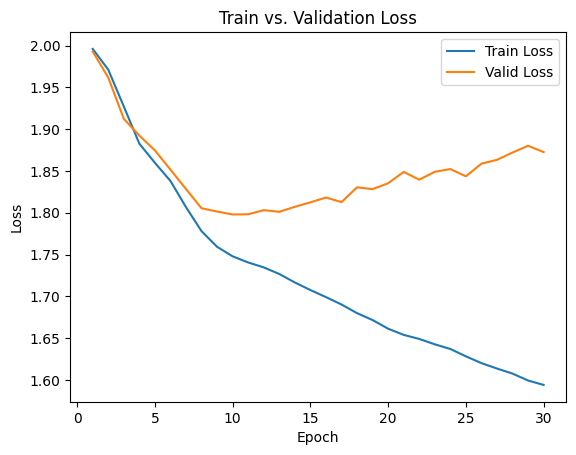

In [47]:
plot_losses(train_losses, valid_losses)

In [25]:
import torch
import torch.nn as nn

def train_autoencoder_tweaked(model, train_loader, valid_loader, device, lr=1e-4, epochs=10, patience=5,
                    scheduler_factor=0.5, scheduler_patience=2):
    """
    Trains the model (autoencoder) using MSE loss with early stopping and a learning rate scheduler.
    
    The model's forward should return a tuple:
        (labels, predicted_stats, all_indexes, all_names, all_teams_embed)
    where:
        - labels: Ground truth stats (Tensor)
        - predicted_stats: The reconstructed stats (Tensor)
    
    Args:
        model: Your autoencoder model (e.g., TeamEmbedding).
        train_loader: DataLoader for training samples.
        valid_loader: DataLoader for validation samples.
        device: The device to use ('cuda' or 'cpu').
        lr: Learning rate.
        epochs: Maximum number of training epochs.
        patience: Number of epochs to wait for improvement in validation loss before stopping.
        scheduler_factor: Factor by which to reduce the learning rate.
        scheduler_patience: Number of epochs with no improvement after which LR is reduced.
    
    Returns:
        (train_losses, valid_losses): Lists of average loss per epoch (up to early stopping).
    """
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # Set up a learning rate scheduler that reduces LR when validation loss plateaus.
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                        factor=scheduler_factor, 
                                                        patience=scheduler_patience, 
                                                        verbose=True)
    
    train_losses = []
    valid_losses = []

    best_valid_loss = float('inf')
    patience_counter = 0
    best_epoch = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0

        for batch in train_loader:
            # Move all tensor data in the batch to the target device.
            for key in batch:
                if torch.is_tensor(batch[key]):
                    batch[key] = batch[key].to(device)
            
            optimizer.zero_grad()
            # Forward pass: get labels and reconstructed stats.
            labels, predicted_stats, all_indexes, all_names, all_teams_embed = model(batch)
            loss = criterion(predicted_stats, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * predicted_stats.size(0)
        
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        running_valid_loss = 0.0
        with torch.no_grad():
            for batch in valid_loader:
                for key in batch:
                    if torch.is_tensor(batch[key]):
                        batch[key] = batch[key].to(device)
                
                labels, predicted_stats, all_indexes, all_names, all_teams_embed = model(batch)
                loss = criterion(predicted_stats, labels)
                running_valid_loss += loss.item() * predicted_stats.size(0)
        
        epoch_valid_loss = running_valid_loss / len(valid_loader.dataset)
        valid_losses.append(epoch_valid_loss)

        # Step the scheduler with the validation loss.
        scheduler.step(epoch_valid_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.4f} | Valid Loss: {epoch_valid_loss:.4f}")

        # Early stopping check.
        if epoch_valid_loss < best_valid_loss:
            best_valid_loss = epoch_valid_loss
            best_epoch = epoch
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}. Best validation loss: {best_valid_loss:.4f} at epoch {best_epoch+1}.")
                break

    # Optionally, load the best model state.
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return train_losses, valid_losses

# Example usage:
# train_losses, valid_losses = train_autoencoder(model, train_loader, valid_loader, device='cuda', lr=1e-4, epochs=20, patience=5)


In [26]:
train_losses, valid_losses = train_autoencoder_tweaked(test_embedder, train_loader, val_loader, device='cuda',
                                                        lr=1e-3, epochs=100, patience=5,
                                                        scheduler_factor=0.1, scheduler_patience=2)

c:\Users\luisi\Documents\Programming\Python\Market\market_env\Lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/100 - Train Loss: 1.9877 | Valid Loss: 2.0399
Epoch 2/100 - Train Loss: 1.8621 | Valid Loss: 1.9661
Epoch 3/100 - Train Loss: 1.7978 | Valid Loss: 1.9421
Epoch 4/100 - Train Loss: 1.7624 | Valid Loss: 1.9285
Epoch 5/100 - Train Loss: 1.7440 | Valid Loss: 1.9286
Epoch 6/100 - Train Loss: 1.7281 | Valid Loss: 1.9122
Epoch 7/100 - Train Loss: 1.7152 | Valid Loss: 1.9139
Epoch 8/100 - Train Loss: 1.7056 | Valid Loss: 1.9109
Epoch 9/100 - Train Loss: 1.6976 | Valid Loss: 1.9093
Epoch 10/100 - Train Loss: 1.6900 | Valid Loss: 1.9120
Epoch 11/100 - Train Loss: 1.6837 | Valid Loss: 1.9097
Epoch 12/100 - Train Loss: 1.6780 | Valid Loss: 1.9127
Epoch 13/100 - Train Loss: 1.6661 | Valid Loss: 1.9120
Epoch 14/100 - Train Loss: 1.6639 | Valid Loss: 1.9112
Early stopping triggered at epoch 14. Best validation loss: 1.9093 at epoch 9.


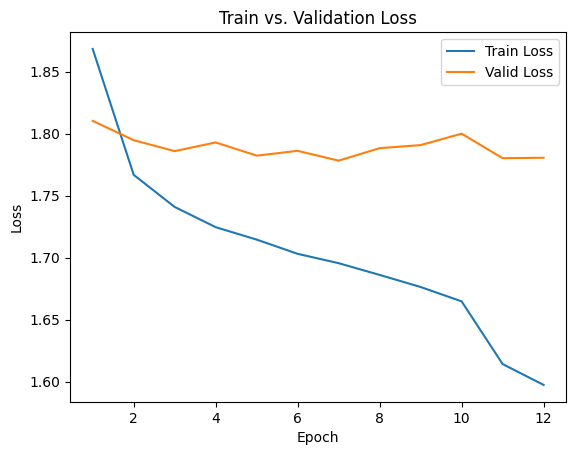

In [16]:
plot_losses(train_losses, valid_losses)

In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize_embeddings(model, test_loader, device='cuda'):
    """
    Visualize team embeddings from the test dataloader using t-SNE.
    
    The model's forward is assumed to return a tuple:
         (labels, predicted_stats, team_ids, names, embeddings)
    where:
         - embeddings: Tensor of shape (batch_size, d) or (batch_size, 1, d)
         - team_ids:   Tensor of shape (batch_size,) with team IDs
         - names:      A list of team names for each sample in the batch
         
    Only one embedding per unique team is selected globally (across all batches).
    """
    model.eval()
    all_embeddings = []
    all_team_ids = []  # list of team IDs (as Python ints)
    all_names = []     # corresponding team names

    with torch.no_grad():
        for batch in test_loader:
            # Move tensors in the batch to the target device.
            for key in batch:
                if torch.is_tensor(batch[key]):
                    batch[key] = batch[key].to(device)
            # Assume model returns: (labels, predicted_stats, team_ids, names, embeddings)
            _, _, team_ids, names, embeddings = model(batch)
            team_ids = team_ids.squeeze().cpu().tolist()  # ensure team_ids is a list of scalars
            all_team_ids.extend(team_ids)
            all_names.extend(names)
            all_embeddings.append(embeddings.cpu().numpy())

    # Concatenate embeddings from all batches.
    all_embeddings = np.concatenate(all_embeddings, axis=0)
    
    # If embeddings have an extra singleton dimension (e.g. shape (batch_size, 1, d)), squeeze it.
    if all_embeddings.ndim == 3 and all_embeddings.shape[1] == 1:
        all_embeddings = np.squeeze(all_embeddings, axis=1)
    
    # Select one embedding per unique team globally.
    unique_embeddings = []
    unique_team_ids = []
    unique_names = []
    seen = set()
    for i, tid in enumerate(all_team_ids):
        if tid not in seen:
            seen.add(tid)
            # Squeeze the embedding in case it has an extra dimension.
            unique_embeddings.append(np.squeeze(all_embeddings[i]))
            unique_team_ids.append(tid)
            unique_names.append(all_names[i])
    unique_embeddings = np.array(unique_embeddings)

    # Apply t-SNE to reduce dimensions to 2.
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    tsne_results = tsne.fit_transform(unique_embeddings)

    # Plot the t-SNE result.
    plt.figure(figsize=(10, 8))
    plt.scatter(tsne_results[:, 0], tsne_results[:, 1], s=10, alpha=0.7, c='blue')

    # Annotate each unique team point with its name.
    for i, name in enumerate(unique_names):
        plt.annotate(name, (tsne_results[i, 0], tsne_results[i, 1]),
                     fontsize=10, alpha=0.75)

    plt.title("t-SNE Visualization of Unique Team Embeddings")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.tight_layout()
    plt.show()

# Example usage:
# visualize_embeddings(test_embedder, test_loader, device='cuda')


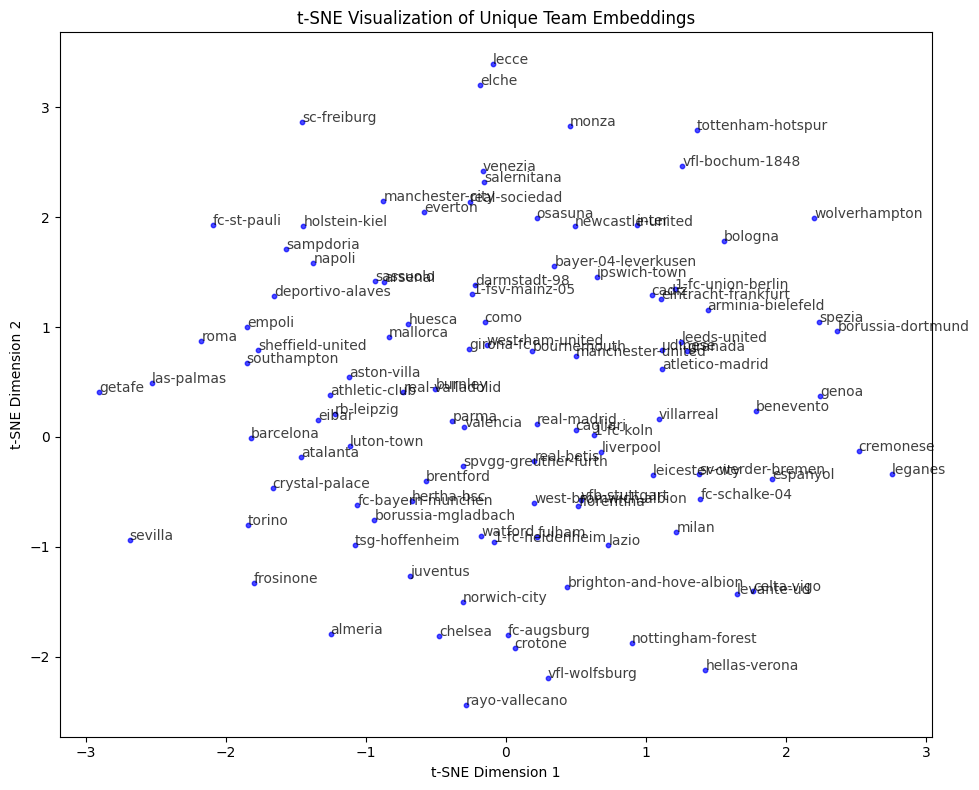

In [28]:
visualize_embeddings(test_embedder, test_loader, device='cuda')

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

def visualize_embeddings(model, test_loader, device='cuda'):
    """
    Visualize team embeddings from the test dataloader using t-SNE after centering and scaling.

    The model's forward is assumed to return a tuple:
        (labels, predicted_stats, team_ids, names, embeddings)
    where:
        - embeddings: Tensor of shape (batch_size, d) or (batch_size, 1, d)
        - team_ids:   Tensor of shape (batch_size,) with team IDs
        - names:      A list of team names for each sample in the batch
        
    Only one embedding per unique team is selected globally (across all batches).
    """
    model.eval()
    all_embeddings = []
    all_team_ids = []  # list of team IDs (as Python ints)
    all_names = []     # corresponding team names

    with torch.no_grad():
        for batch in test_loader:
            # Move tensors in the batch to the target device.
            for key in batch:
                if torch.is_tensor(batch[key]):
                    batch[key] = batch[key].to(device)
            # Assume model returns: (labels, predicted_stats, team_ids, names, embeddings)
            _, _, team_ids, names, embeddings = model(batch)
            team_ids = team_ids.squeeze().cpu().tolist()  # ensure team_ids is a list of scalars
            all_team_ids.extend(team_ids)
            all_names.extend(names)
            all_embeddings.append(embeddings.cpu().numpy())

    # Concatenate embeddings from all batches.
    all_embeddings = np.concatenate(all_embeddings, axis=0)
    
    # If embeddings have an extra singleton dimension (e.g. shape (batch_size, 1, d)), squeeze it.
    if all_embeddings.ndim == 3 and all_embeddings.shape[1] == 1:
        all_embeddings = np.squeeze(all_embeddings, axis=1)
    
    # Select one embedding per unique team globally.
    unique_embeddings = []
    unique_team_ids = []
    unique_names = []
    seen = set()
    for i, tid in enumerate(all_team_ids):
        if tid not in seen:
            seen.add(tid)
            # Squeeze the embedding in case it has an extra dimension.
            unique_embeddings.append(np.squeeze(all_embeddings[i]))
            unique_team_ids.append(tid)
            unique_names.append(all_names[i])
    unique_embeddings = np.array(unique_embeddings)

    # Center and scale the embeddings before applying t-SNE.
    scaler = StandardScaler()
    unique_embeddings = scaler.fit_transform(unique_embeddings)

    # Apply t-SNE to reduce dimensions to 2.
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    tsne_results = tsne.fit_transform(unique_embeddings)

    # Plot the t-SNE result.
    plt.figure(figsize=(10, 8))
    plt.scatter(tsne_results[:, 0], tsne_results[:, 1], s=50, alpha=0.7, c='blue')

    # Annotate each unique team point with its name.
    for i, name in enumerate(unique_names):
        plt.annotate(name, (tsne_results[i, 0], tsne_results[i, 1]),
                     fontsize=10, alpha=0.75)

    plt.title("t-SNE Visualization of Unique Team Embeddings (Centered & Scaled)")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.tight_layout()
    plt.show()

# Example usage:
# visualize_embeddings(test_embedder, test_loader, device='cuda')


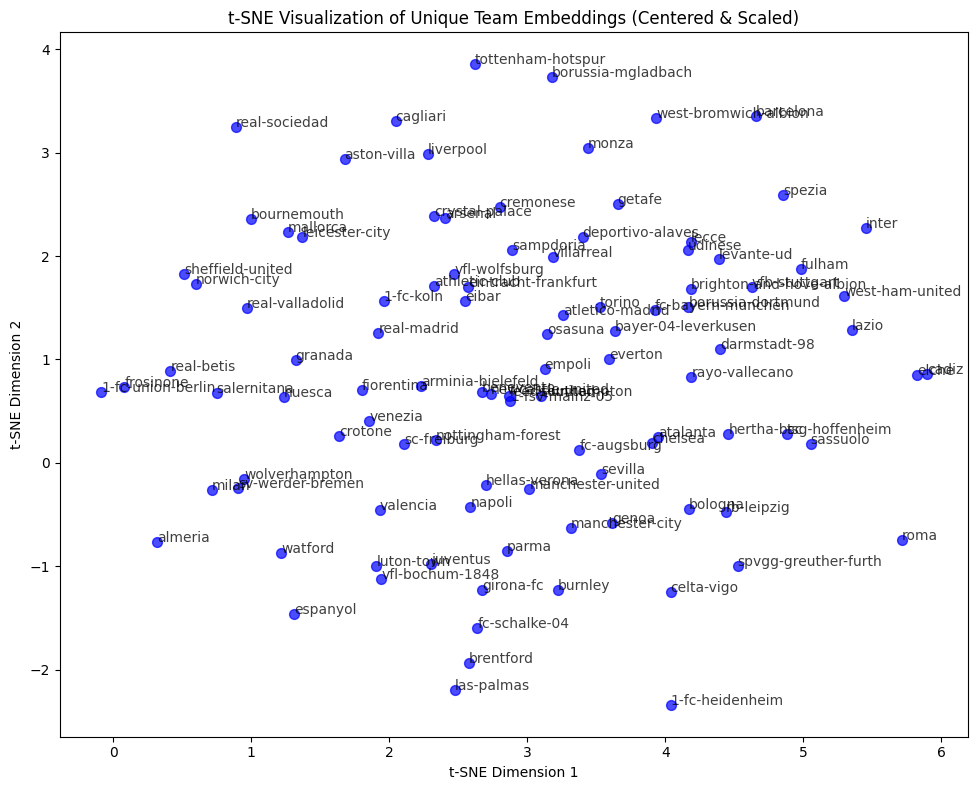

In [105]:
visualize_embeddings(test_embedder, test_loader, device='cuda')

In [83]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def visualize_embeddings_pca(model, test_loader, device='cuda', component_x=0, component_y=1):
    """
    Visualize team embeddings from the test dataloader using PCA.
    
    The model's forward is assumed to return a tuple:
         (labels, predicted_stats, team_ids, names, embeddings)
    where:
         - embeddings: Tensor of shape (batch_size, d) or (batch_size, 1, d)
         - team_ids:   Tensor of shape (batch_size,) with team IDs
         - names:      A list of team names for each sample in the batch
         
    Only one embedding per unique team is selected globally (across all batches).
    
    Parameters:
        model: The model from which to extract embeddings.
        test_loader: DataLoader providing test data.
        device: Device on which to run computations ('cuda' or 'cpu').
        component_x: Index of the PCA component to use for the x-axis (0-indexed).
        component_y: Index of the PCA component to use for the y-axis (0-indexed).
    """
    model.eval()
    all_embeddings = []
    all_team_ids = []  # list of team IDs (as Python ints)
    all_names = []     # corresponding team names

    with torch.no_grad():
        for batch in test_loader:
            # Move each tensor in the batch to the specified device.
            for key in batch:
                if torch.is_tensor(batch[key]):
                    batch[key] = batch[key].to(device)
            # Assume model returns: (labels, predicted_stats, team_ids, names, embeddings)
            _, _, team_ids, names, embeddings = model(batch)
            # Squeeze team_ids so that we get scalars, then convert to list.
            team_ids = team_ids.squeeze().cpu().tolist()
            all_team_ids.extend(team_ids)
            all_names.extend(names)
            all_embeddings.append(embeddings.cpu().numpy())

    # Concatenate embeddings from all batches.
    all_embeddings = np.concatenate(all_embeddings, axis=0)
    
    # If embeddings have an extra singleton dimension (shape (N,1,d)), squeeze it.
    if all_embeddings.ndim == 3 and all_embeddings.shape[1] == 1:
        all_embeddings = np.squeeze(all_embeddings, axis=1)
    
    # Select one embedding per unique team globally.
    unique_embeddings = []
    unique_team_ids = []
    unique_names = []
    seen = set()
    for i, tid in enumerate(all_team_ids):
        if tid not in seen:
            seen.add(tid)
            unique_embeddings.append(all_embeddings[i])
            unique_team_ids.append(tid)
            unique_names.append(all_names[i])
    unique_embeddings = np.array(unique_embeddings)

    # Ensure PCA computes enough components.
    n_components = max(component_x, component_y) + 1
    pca = PCA(n_components=n_components)
    pca_results = pca.fit_transform(unique_embeddings)

    # Extract the chosen components for visualization.
    x_vals = pca_results[:, component_x]
    y_vals = pca_results[:, component_y]

    # Plot the PCA results.
    plt.figure(figsize=(10, 8))
    plt.scatter(x_vals, y_vals, s=50, alpha=0.7, c='blue')

    # Annotate each unique team point with its name.
    for i, name in enumerate(unique_names):
        plt.annotate(name, (x_vals[i], y_vals[i]), fontsize=10, alpha=0.75)

    plt.title("PCA Visualization of Unique Team Embeddings")
    plt.xlabel(f"PCA Component {component_x + 1}")
    plt.ylabel(f"PCA Component {component_y + 1}")
    plt.tight_layout()
    plt.show()

# Example usage:
# visualize_embeddings_pca(test_embedder, test_loader, device='cuda', component_x=0, component_y=1)


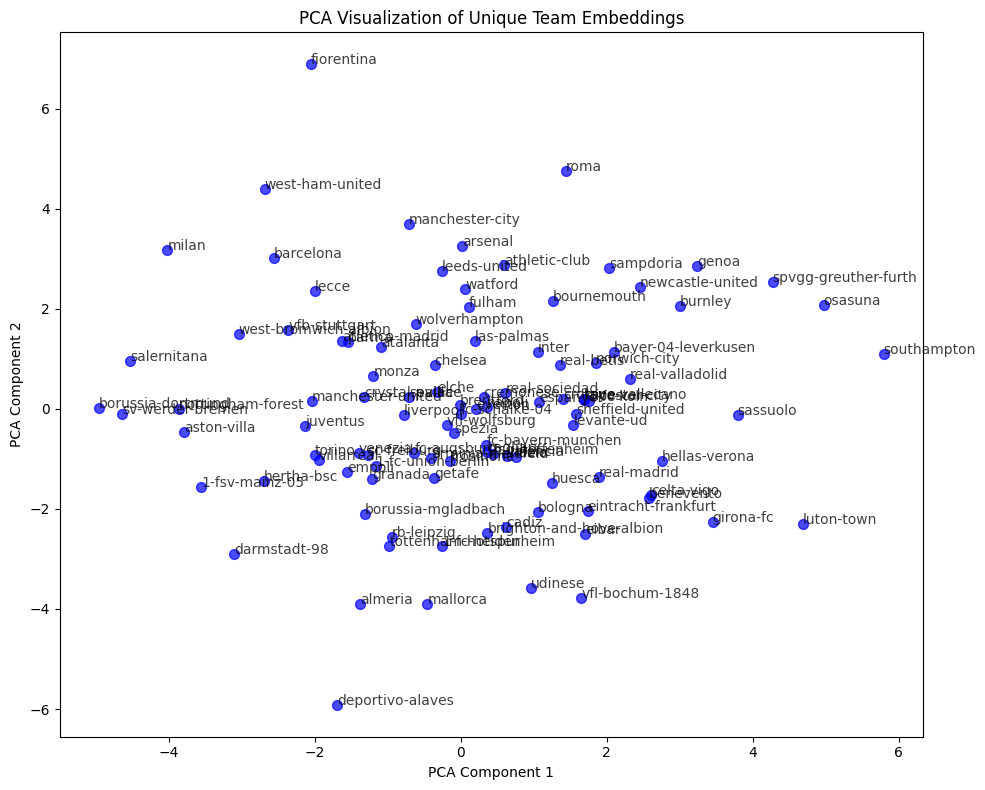

In [84]:
visualize_embeddings_pca(test_embedder, test_loader, device='cuda', component_x=0, component_y=1)

In [85]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def visualize_embeddings_pca(model, test_loader, device='cuda', component_x=0, component_y=1):
    """
    Visualize team embeddings from the test dataloader using PCA after centering and scaling.
    
    The model's forward is assumed to return a tuple:
         (labels, predicted_stats, team_ids, names, embeddings)
    where:
         - embeddings: Tensor of shape (batch_size, d) or (batch_size, 1, d)
         - team_ids:   Tensor of shape (batch_size,) with team IDs
         - names:      A list of team names for each sample in the batch
         
    Only one embedding per unique team is selected globally (across all batches).
    
    Parameters:
        model: The model from which to extract embeddings.
        test_loader: DataLoader providing test data.
        device: Device on which to run computations ('cuda' or 'cpu').
        component_x: Index of the PCA component to use for the x-axis (0-indexed).
        component_y: Index of the PCA component to use for the y-axis (0-indexed).
    """
    model.eval()
    all_embeddings = []
    all_team_ids = []  # list of team IDs (as Python ints)
    all_names = []     # corresponding team names

    with torch.no_grad():
        for batch in test_loader:
            # Move each tensor in the batch to the specified device.
            for key in batch:
                if torch.is_tensor(batch[key]):
                    batch[key] = batch[key].to(device)
            # Assume model returns: (labels, predicted_stats, team_ids, names, embeddings)
            _, _, team_ids, names, embeddings = model(batch)
            # Squeeze team_ids so that we get scalars, then convert to list.
            team_ids = team_ids.squeeze().cpu().tolist()
            all_team_ids.extend(team_ids)
            all_names.extend(names)
            all_embeddings.append(embeddings.cpu().numpy())

    # Concatenate embeddings from all batches.
    all_embeddings = np.concatenate(all_embeddings, axis=0)
    
    # If embeddings have an extra singleton dimension (shape (N,1,d)), squeeze it.
    if all_embeddings.ndim == 3 and all_embeddings.shape[1] == 1:
        all_embeddings = np.squeeze(all_embeddings, axis=1)
    
    # Select one embedding per unique team globally.
    unique_embeddings = []
    unique_team_ids = []
    unique_names = []
    seen = set()
    for i, tid in enumerate(all_team_ids):
        if tid not in seen:
            seen.add(tid)
            unique_embeddings.append(all_embeddings[i])
            unique_team_ids.append(tid)
            unique_names.append(all_names[i])
    unique_embeddings = np.array(unique_embeddings)

    # Center and scale the embeddings before applying PCA.
    scaler = StandardScaler()
    unique_embeddings = scaler.fit_transform(unique_embeddings)

    # Ensure PCA computes enough components.
    n_components = max(component_x, component_y) + 1
    pca = PCA(n_components=n_components)
    pca_results = pca.fit_transform(unique_embeddings)

    # Extract the chosen components for visualization.
    x_vals = pca_results[:, component_x]
    y_vals = pca_results[:, component_y]

    # Plot the PCA results.
    plt.figure(figsize=(10, 8))
    plt.scatter(x_vals, y_vals, s=50, alpha=0.7, c='blue')

    # Annotate each unique team point with its name.
    for i, name in enumerate(unique_names):
        plt.annotate(name, (x_vals[i], y_vals[i]), fontsize=10, alpha=0.75)

    plt.title("PCA Visualization of Unique Team Embeddings (Centered & Scaled)")
    plt.xlabel(f"PCA Component {component_x + 1}")
    plt.ylabel(f"PCA Component {component_y + 1}")
    plt.tight_layout()
    plt.show()

# Example usage:
# visualize_embeddings_pca(test_embedder, test_loader, device='cuda', component_x=0, component_y=1)


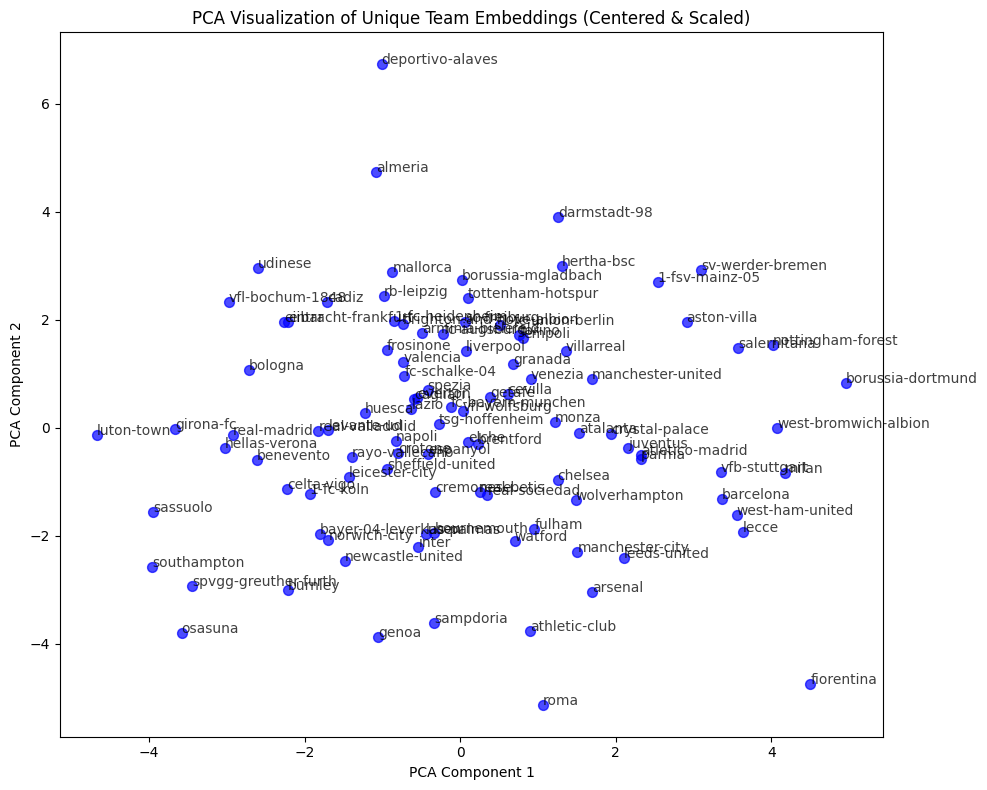

In [86]:
visualize_embeddings_pca(test_embedder, test_loader, device='cuda', component_x=0, component_y=1)

In [30]:
def test_embedding_equality_by_name(model, test_loader, device='cuda', atol=1e-6, rtol=1e-5):
    """
    For each unique team name in the test_loader, check whether all embeddings
    (returned by the model) for that team are equal (using torch.allclose).

    The model's forward is assumed to return a tuple:
         (_, team_ids, names, embeddings)
    where:
         - names: a list of team names (one per sample)
         - embeddings: Tensor of shape (batch_size, d)

    Args:
        model: The model (e.g., your TeamEmbedding module).
        test_loader: DataLoader for the test set.
        device: Device string.
        atol, rtol: Tolerances for torch.allclose.
    """
    model.eval()
    all_embeddings = []
    all_names = []  # list of team names

    with torch.no_grad():
        for batch in test_loader:
            for key in batch:
                if torch.is_tensor(batch[key]):
                    batch[key] = batch[key].to(device)
            # Assume model returns: (_, team_ids, names, embeddings)
            _,_, team_ids, names, embeddings = model(batch)
            all_names.extend(names)
            all_embeddings.append(embeddings.cpu())

    # Concatenate all embeddings along the batch dimension.
    all_embeddings = torch.cat(all_embeddings, dim=0)
    
    # Ensure the names list matches the number of embeddings.
    n_points = all_embeddings.shape[0]
    all_names = all_names[:n_points]

    # Group embeddings by team name.
    name_to_embeds = {}
    for i, name in enumerate(all_names):
        if name not in name_to_embeds:
            name_to_embeds[name] = []
        name_to_embeds[name].append(all_embeddings[i])

    # Check equality within each group.
    for name, embeds in name_to_embeds.items():
        if len(embeds) < 2:
            print(f"Team '{name}': Only one instance, skipping.")
        else:
            base = embeds[0]
            equal = all(torch.allclose(emb, base, atol=atol, rtol=rtol) for emb in embeds[1:])
            if equal:
                print(f"Team '{name}': Equal")
            else:
                print(f"Team '{name}': Not Equal")

# Example usage:
# test_embedding_equality_by_name(test_embedder, test_loader, device='cuda')


In [31]:
test_embedding_equality_by_name(test_embedder, test_loader, device='cuda')

Team 'southampton': Equal
Team 'brighton-and-hove-albion': Equal
Team 'aston-villa': Equal
Team 'levante-ud': Equal
Team 'celta-vigo': Equal
Team 'eibar': Equal
Team 'elche': Equal
Team 'huesca': Equal
Team 'osasuna': Equal
Team 'real-madrid': Equal
Team 'real-valladolid': Equal
Team 'granada': Equal
Team 'sevilla': Equal
Team 'fulham': Equal
Team 'athletic-club': Equal
Team 'atletico-madrid': Equal
Team 'cadiz': Equal
Team 'getafe': Equal
Team 'mallorca': Equal
Team 'real-betis': Equal
Team 'villarreal': Equal
Team 'rayo-vallecano': Equal
Team 'leeds-united': Equal
Team 'valencia': Equal
Team 'deportivo-alaves': Equal
Team 'barcelona': Equal
Team 'real-sociedad': Equal
Team 'almeria': Equal
Team 'leicester-city': Equal
Team 'girona-fc': Equal
Team 'liverpool': Equal
Team 'espanyol': Equal
Team 'manchester-city': Equal
Team 'sheffield-united': Equal
Team 'las-palmas': Equal
Team 'west-ham-united': Equal
Team 'leganes': Equal
Team 'wolverhampton': Equal
Team 'spezia': Equal
Team 'juvent

In [32]:
for key in batch_data:
                if torch.is_tensor(batch_data[key]):
                    batch_data[key] = batch_data[key].to('cuda')
labels_t, home_away_stats_t, all_indexes_t, all_names_t, all_teams_embed_t= test_embedder(batch_data)

In [25]:
labels_t[0]

tensor([-2.3307e-01, -6.3304e-01, -6.0173e-01, -8.5661e-01,  5.3097e-02,
        -4.1106e-01, -1.6855e-01, -9.5507e-01, -2.9677e-01, -1.7456e+00,
        -5.1837e-01, -1.0477e+00, -1.3515e+00, -4.0555e-01, -4.7873e-01,
        -8.5750e-01, -5.9351e-01, -7.1974e-01, -4.8775e-01, -2.9331e-02,
        -1.0678e+00, -4.6652e-01, -1.2696e+00, -6.8896e-01, -1.2057e+00,
        -1.3040e+00, -2.0692e-02, -4.7955e-01, -9.3459e-02, -6.5603e-01,
         7.3506e-01, -2.0743e-01, -2.0831e-01, -4.2865e-01, -7.2694e-02,
        -1.3598e+00, -1.5036e-01, -5.0446e-01, -7.8207e-01,  9.1991e-04,
         1.5694e+00, -1.2671e-01, -9.5286e-03,  8.1578e-03, -1.5234e-01,
        -9.9361e-01,  9.0404e-01, -5.6611e-01,  7.1739e-02, -2.9686e-01,
         4.2332e-01, -8.0791e-01, -2.3999e-01,  1.3227e+00,  8.8378e-02,
         2.5685e-01,  1.4533e-01, -6.6719e-01, -1.0556e+00, -9.8589e-02,
        -3.8757e-01,  5.6745e-02, -1.4096e-01, -1.5970e-01,  3.1881e-01,
         2.2736e-01,  1.0298e+00, -2.8721e-01, -2.5

In [43]:
home_away_stats_t[1]-labels_t[1]

tensor([ 0.6051,  1.2010,  0.4847,  0.1724,  0.5521,  1.3162,  0.9808, -0.1056,
         0.8281,  0.6111,  0.8829,  0.1445, -1.0839,  0.2305,  0.9325, -0.5849,
        -0.7659, -0.0584,  1.0313,  0.2913, -1.0450,  0.3395, -0.4006,  1.0195,
         0.3073, -0.9185,  0.8960,  0.9309,  1.2139,  0.9465,  0.8454,  1.1680,
         1.1498,  0.8376,  1.1122,  1.2188,  0.3437, -0.1434, -0.8029,  1.0362,
        -0.5374, -0.2316, -0.0344, -0.2298,  0.5347, -0.2668,  0.1462,  0.9290,
         0.4146,  0.2337, -0.0845, -0.4989,  0.4205, -0.1276, -0.7841, -0.4517,
        -0.0179, -0.1455,  0.4961, -1.2213,  0.8839,  0.8686,  0.2176,  0.5428,
        -0.5757,  1.3388, -0.5958,  0.4157,  0.4169, -0.3527,  0.9097, -0.8560,
         1.4315,  0.4360, -0.1601,  0.1493, -0.6673, -0.1643], device='cuda:0',
       grad_fn=<SubBackward0>)

In [36]:
reference_t=torch.cat([mu_atk, mu_def], dim=0).to('cuda')
sigma_t = torch.cat([sigma_atk, sigma_def], dim=0).to('cuda')  

In [51]:
all_header[5]

'total_finalthirdentries'

In [167]:
test_ind = 106
torch.set_printoptions(sci_mode=False) 
((home_away_stats_t[test_ind]*sigma_t)-(labels_t[test_ind]*sigma_t))[4]

tensor(1.0578, device='cuda:0', dtype=torch.float64, grad_fn=<SelectBackward0>)

In [168]:
((home_away_stats_t[test_ind]*sigma_t)+reference_t)[4]

tensor(4.0578, device='cuda:0', dtype=torch.float64, grad_fn=<SelectBackward0>)

In [44]:
b_size = home_away_stats_t.shape[0]//2
home_corners = ((home_away_stats_t*sigma_t)+reference_t)[:b_size,4]
away_corners = ((home_away_stats_t*sigma_t)+reference_t)[b_size:,4]
home_names = all_names_t[:b_size]
away_names = all_names_t[b_size:]
home_labels = ((labels_t*sigma_t)+reference_t)[:b_size,4]
away_labels = ((labels_t*sigma_t)+reference_t)[b_size:,4]
all_corners = home_corners+away_corners
all_labels = home_labels+away_labels

In [ ]:
for i in range(len(all_corners)):
    print(home_names[i], home_corners[i], home_labels[i], away_names[i], away_corners[i], away_labels[i], all_corners[i], all_labels[i])

In [51]:
# Define header with fixed-width columns.
header = (
    f"{'Home Name':<25} {'Home Predicted':<15} {'Home Corners':<15} "
    f"{'Away Name':<25} {'Away Predicted':<15} {'Away Corners':<15} "
    f"{'All Predicted':<15} {'All Corners':<15}"
)
print(header)
print("-" * len(header))

# Print each row with float values truncated to 2 decimal places.
for i in range(len(all_corners)):
    row = (
        f"{home_names[i]:<25} "
        f"{home_corners[i]:<15.2f} "
        f"{home_labels[i]:<15.2f} "
        f"{away_names[i]:<25} "
        f"{away_corners[i]:<15.2f} "
        f"{away_labels[i]:<15.2f} "
        f"{all_corners[i]:<15.2f} "
        f"{all_labels[i]:<15.2f}"
    )
    print(row)

Home Name                 Home Predicted  Home Corners    Away Name                 Away Predicted  Away Corners    All Predicted   All Corners    
---------------------------------------------------------------------------------------------------------------------------------------------------
southampton               4.91            4.00            leeds-united              5.09            4.00            10.00           8.00           
brighton-and-hove-albion  3.82            5.00            manchester-city           5.76            3.00            9.59            8.00           
aston-villa               4.50            2.00            chelsea                   5.34            9.00            9.84            11.00          
levante-ud                5.19            7.00            cadiz                     3.52            -0.00           8.70            7.00           
celta-vigo                4.86            8.00            real-betis                3.79            4.00        

In [208]:
all_corners = ((home_away_stats_t*sigma_t)-(labels_t*sigma_t))

In [47]:
all_header = atk_headers+def_headers

In [230]:
all_corners+reference_t[4]

tensor([4.6118, 5.4113, 4.4523, 5.2212, 4.9733, 5.3938, 4.8966, 4.1953, 6.3226,
        5.4458, 5.0289, 5.9411, 5.6215, 5.6062, 5.0750, 5.3168, 6.0348, 4.4520,
        5.6333, 4.2576, 4.4681, 6.0291, 5.4989, 5.9907, 5.2679, 4.7032, 6.9758,
        3.9163, 5.0758, 5.8295, 4.4718, 5.1754, 4.9147, 5.2021, 5.9532, 6.1699,
        5.4196, 5.9455, 5.7886, 6.1349, 5.6308, 5.0655, 4.9023, 5.0211, 4.5153,
        6.7641, 4.3193, 4.9660, 4.8832, 4.3297, 4.4025, 6.2827, 6.1314, 6.3160,
        4.2777, 5.1416, 5.0656, 4.1736, 5.5302, 4.7645, 4.0977, 5.1043, 4.4344,
        4.6618, 4.8279, 5.0801, 5.3226, 4.2578, 5.4125, 4.2856, 4.7657, 3.4875,
        3.8591, 5.1210, 3.3665, 4.6437, 4.5085, 4.9406, 4.1983, 5.6370, 3.9894,
        5.1450, 4.5118, 4.8712, 4.2061, 4.4299, 5.4453, 6.4958, 3.7942, 4.8878,
        6.0674, 4.9445, 5.3617, 4.8071, 3.8094, 3.8481, 3.5113, 4.4305, 5.2017,
        5.2601, 2.9400, 4.2560, 3.1837, 6.3428, 4.8175, 4.1234, 4.3711, 4.2523,
        5.9110, 4.6732, 4.9491, 4.9371, 

In [91]:
all_names_t

['sheffield-united',
 'manchester-city',
 'newcastle-united',
 'west-ham-united',
 'brighton-and-hove-albion',
 'manchester-city',
 'newcastle-united',
 'arsenal',
 'aston-villa',
 'brentford',
 'chelsea',
 'crystal-palace',
 'everton',
 'burnley',
 'leeds-united',
 'leicester-city',
 'manchester-united',
 'southampton',
 'manchester-united',
 'newcastle-united',
 'wolverhampton',
 'everton',
 'aston-villa',
 'bournemouth',
 'southampton',
 'tottenham-hotspur',
 'nottingham-forest',
 'luton-town',
 'arsenal',
 'brentford',
 'burnley',
 'sheffield-united',
 'manchester-city',
 'brighton-and-hove-albion',
 'chelsea',
 'brighton-and-hove-albion',
 'liverpool',
 'crystal-palace',
 'fulham',
 'bournemouth',
 'everton',
 'newcastle-united',
 'tottenham-hotspur',
 'west-ham-united',
 'wolverhampton',
 'nottingham-forest',
 'crystal-palace',
 'manchester-united',
 'aston-villa',
 'arsenal',
 'brentford',
 'brighton-and-hove-albion',
 'burnley',
 'chelsea',
 'crystal-palace',
 'liverpool',
 'lu

In [158]:
[i for i in range(len(all_names_t)) if all_names_t[i]=='burnley']   

[13, 30, 52, 82, 106]

In [157]:
all_header

['total_accuratepasses',
 'total_accuratethroughball',
 'total_bigchancecreated',
 'total_bigchancescored',
 'total_cornerkicks',
 'total_finalthirdentries',
 'total_fouledfinalthird',
 'total_freekicks',
 'total_passes',
 'total_shotsongoal',
 'total_totalshotsinsidebox',
 'total_totalshotsongoal',
 'total_totalshotsoutsidebox',
 '45_min_accuratepasses',
 '45_min_accuratethroughball',
 '45_min_bigchancecreated',
 '45_min_bigchancescored',
 '45_min_cornerkicks',
 '45_min_finalthirdentries',
 '45_min_fouledfinalthird',
 '45_min_freekicks',
 '45_min_passes',
 '45_min_shotsongoal',
 '45_min_totalshotsinsidebox',
 '45_min_totalshotsongoal',
 '45_min_totalshotsoutsidebox',
 '90_min_accuratepasses',
 '90_min_accuratethroughball',
 '90_min_bigchancecreated',
 '90_min_bigchancescored',
 '90_min_cornerkicks',
 '90_min_finalthirdentries',
 '90_min_fouledfinalthird',
 '90_min_freekicks',
 '90_min_passes',
 '90_min_shotsongoal',
 '90_min_totalshotsinsidebox',
 '90_min_totalshotsongoal',
 '90_min_t

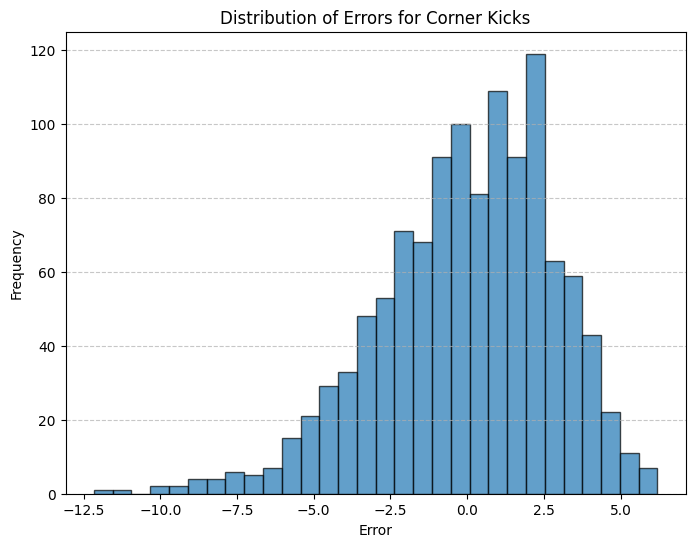

In [191]:
import numpy as np
import matplotlib.pyplot as plt

# Compute the errors for the entire batch, move to CPU, detach, and convert to numpy
errors = [((home_away_stats_t[i].cpu().detach() * sigma_t.cpu().detach()) - 
          (labels_t[i].cpu().detach() * sigma_t.cpu().detach()))[4] for i in range(len(labels_t))]

# Convert list of tensors to NumPy and flatten them
errors = np.concatenate([e.numpy().flatten() for e in errors])

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.title('Distribution of Errors for Corner Kicks')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



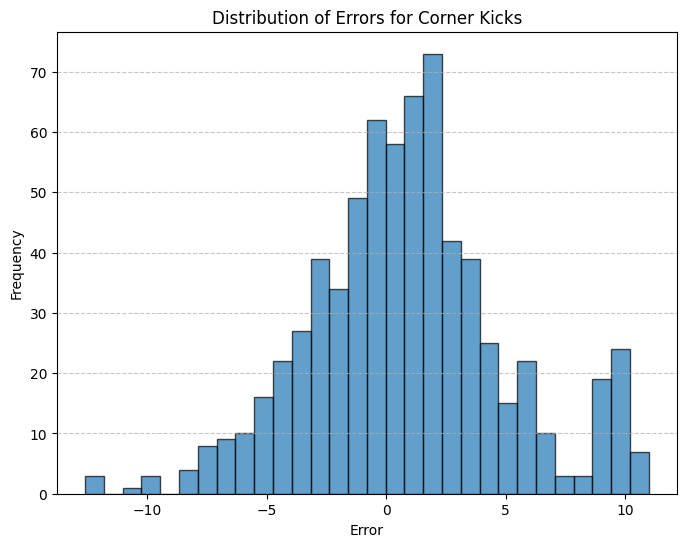

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Compute the errors for the entire batch, move to CPU, detach, and convert to numpy
errors = [(all_corners[i].cpu().detach() - 
        all_labels[i].cpu().detach()) for i in range(len(all_labels))]

# Convert list of tensors to NumPy and flatten them
errors = np.concatenate([e.numpy().flatten() for e in errors])

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.title('Distribution of Errors for Corner Kicks')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [53]:
errors

array([ 1.99919072e+00,  1.58930351e+00, -1.16319095e+00,  1.70434975e+00,
       -3.34490505e+00,  3.10016743e-01,  5.37082232e+00, -2.70668644e+00,
        2.42133153e+00,  3.43602279e+00, -1.62881599e+00, -6.21832200e-01,
       -3.56098263e-01,  1.21918226e+00, -6.50270033e+00, -1.65798879e-01,
       -2.77850286e+00, -3.37261485e+00, -1.31642976e+00,  1.86561260e+00,
        7.47202552e-01, -3.35942029e+00,  2.35654366e+00, -1.45591300e-01,
       -7.77398357e-01, -2.87605548e+00,  2.68026840e+00, -2.66342577e+00,
        7.49954756e-01, -7.16549020e-01, -3.02183805e+00, -3.11391627e+00,
        3.40615305e+00,  4.58983431e+00,  4.21359961e+00, -4.35102467e+00,
       -1.25841716e+01, -1.27804161e+00, -7.61679673e+00,  2.74020277e+00,
        6.48400246e+00, -4.14684905e+00,  1.37392735e-01, -3.89249645e+00,
        7.50545182e-01,  1.82569321e+00, -4.75834432e+00, -7.83872713e-01,
        1.63913983e+00, -3.95096594e+00,  2.85907996e+00, -1.77451148e+00,
       -1.95124058e+00,  

In [65]:
completely_wrong = [errors[i] for i in range(len(errors)) if errors[i]<-4]
len(completely_wrong)

75

In [80]:
def pred_more_than(prediction, true, threshold):
    """
    Count the number of instances where the prediction exceeds the threshold and
    the corresponding true value also exceeds the threshold. Also count the total
    number of predictions that exceed the threshold.
    
    Args:
        prediction (list or iterable): Predicted values.
        true (list or iterable): True values.
        threshold (float): The threshold to compare against.
    
    Returns:
        tuple: (count_success, total_count)
            count_success: Number of times both prediction and true exceed threshold.
            total_count: Total number of times prediction exceeds threshold.
    """
    count_success = 0
    total_count = 0
    for p, t in zip(prediction, true):
        if p > threshold:
            total_count += 1
            if t > threshold-3:
                count_success += 1
    return count_success, total_count



threshold = 7.0
success, total = pred_more_than(all_corners,all_labels, threshold)
print("Success:", success, "Total predictions above threshold:", total)

Success: 623 Total predictions above threshold: 693


In [68]:
pred_more_than(all_corners, all_labels, 7)

499

In [81]:
623/693

0.898989898989899